In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Reader, Dataset, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
sns.set(style='whitegrid')
%matplotlib inline
pd.set_option('display.max_columns', None)

In [2]:
movies_path = '/kaggle/input/movienew/moviesnew.csv'
ratings_path = '/kaggle/input/ratings/ratings_half.csv'

movies_df = pd.read_csv(movies_path)
print("Movies DataFrame Head:")
display(movies_df.head())


ratings_df = pd.read_csv(ratings_path)
print("\nRatings DataFrame Head:")
display(ratings_df.head())

Movies DataFrame Head:


,movieId,title,genres,overview,poster_path,year
0,1,Zootopia 2,Animation|Family|Comedy|Adventure|Mystery,After cracking the biggest case in Zootopia's ...,/oJ7g2CifqpStmoYQyaLQgEU32qO.jpg,2025
1,2,The Shadow's Edge,Action|Crime|Thriller,Macau Police brings the tracking expert police...,/e0RU6KpdnrqFxDKlI3NOqN8nHL6.jpg,2025
2,3,Bureau 749,Action|Adventure|Science Fiction,A traumatized young man with physical abnormal...,/flykCMw22y6yv8vKnBjmsW3pneo.jpg,2024
3,4,Altered,Science Fiction|Action,"In an alternate present, genetically enhanced ...",/6QlAcGRaUrgHcZ4WTBh5lsPnzKx.jpg,2025
4,5,Wildcat,Action|Thriller|Crime,An ex-black ops team reunite to pull off a des...,/h893ImjM6Fsv5DFhKJdlZFZIJno.jpg,2025



Ratings DataFrame Head:


,userId,movieId,rating,timestamp
0,1,1234,5.0,944053948
1,1,2232,3.0,943228696
2,1,908,5.0,944250228
3,1,1178,4.0,943231162
4,1,1944,2.0,943231120


## Kiểm Tra Dữ liệu

In [3]:
print("Movies DataFrame Info:")
movies_df.info()

print("\nMissing Values in Movies DataFrame:")
print(movies_df.isnull().sum())

Movies DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9892 entries, 0 to 9891
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   movieId      9892 non-null   int64 
 1   title        9892 non-null   object
 2   genres       9857 non-null   object
 3   overview     9867 non-null   object
 4   poster_path  9835 non-null   object
 5   year         9892 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 463.8+ KB

Missing Values in Movies DataFrame:
movieId         0
title           0
genres         35
overview       25
poster_path    57
year            0
dtype: int64


In [4]:
print("\nRatings DataFrame Info:")
ratings_df.info()

print("\nMissing Values in Ratings DataFrame:")
print(ratings_df.isnull().sum())


Ratings DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15998927 entries, 0 to 15998926
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 488.2 MB

Missing Values in Ratings DataFrame:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [5]:
df = pd.merge(ratings_df, movies_df, on='movieId', how='left')

print("Merged DataFrame Head:")
display(df.head())

print("\nMerged DataFrame Info:")
df.info()

Merged DataFrame Head:


,userId,movieId,rating,timestamp,title,genres,overview,poster_path,year
0,1,1234,5.0,944053948,Contraband,Thriller|Action|Drama|Crime,When his brother-in-law runs afoul of a drug l...,/dNNjyZQ0zVtmPa74nJE63Kn0xEx.jpg,2012.0
1,1,2232,3.0,943228696,Belle Époque,Comedy|Drama|Romance,"In 1931, a young soldier deserts from the army...",/2pb7i9pI6wMH5dlyjbVTXdfSKun.jpg,1992.0
2,1,908,5.0,944250228,Saltburn,Drama|Comedy|Thriller,Struggling to find his place at Oxford Univers...,/zGTfMwG112BC66mpaveVxoWPOaB.jpg,2023.0
3,1,1178,4.0,943231162,Halo: Nightfall,Science Fiction|Action|Adventure,Set between the events of Halo 4 and Halo 5: G...,/liLQ8EFzHN06eFZ9KQMDK6cmGaK.jpg,2014.0
4,1,1944,2.0,943231120,The Californians,Drama|Comedy,When real estate mogul Gavin Ransom announces ...,/94w3CM4V8AG9OEgtPQSwDfFd6Vw.jpg,2005.0



Merged DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15998927 entries, 0 to 15998926
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   userId       int64  
 1   movieId      int64  
 2   rating       float64
 3   timestamp    int64  
 4   title        object 
 5   genres       object 
 6   overview     object 
 7   poster_path  object 
 8   year         float64
dtypes: float64(2), int64(3), object(4)
memory usage: 1.1+ GB


## Trực Quan Hóa Dữ Liệu

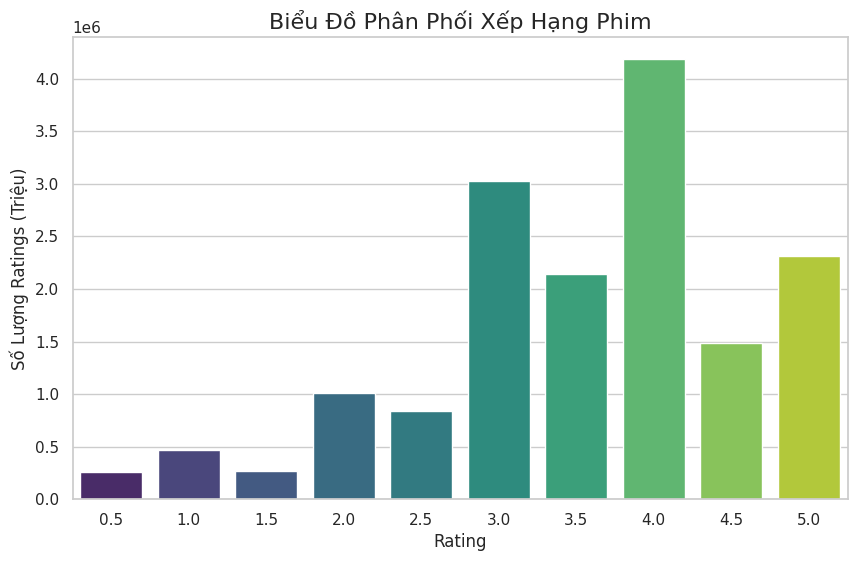

In [6]:
## Biểu Đồ Phân Phối Xếp Hạng Phim
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Biểu Đồ Phân Phối Xếp Hạng Phim', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Số Lượng Ratings (Triệu)', fontsize=12)
plt.show()

Biểu đồ cho thấy rõ ràng người dùng đánh giá tích cực nhiều hơn tiêu cực. Mức đánh giá phổ biến nhất là 4.0, tiếp theo là 3.0. Các mức đánh giá thấp hơn như 1.0 và 0.5 ít phổ biến hơn nhiều. Chúng ta cũng có thể thấy rằng người dùng thích đánh giá toàn sao (ví dụ: 4.0, 3.0) hơn là nửa sao (ví dụ: 3.5, 2.5).

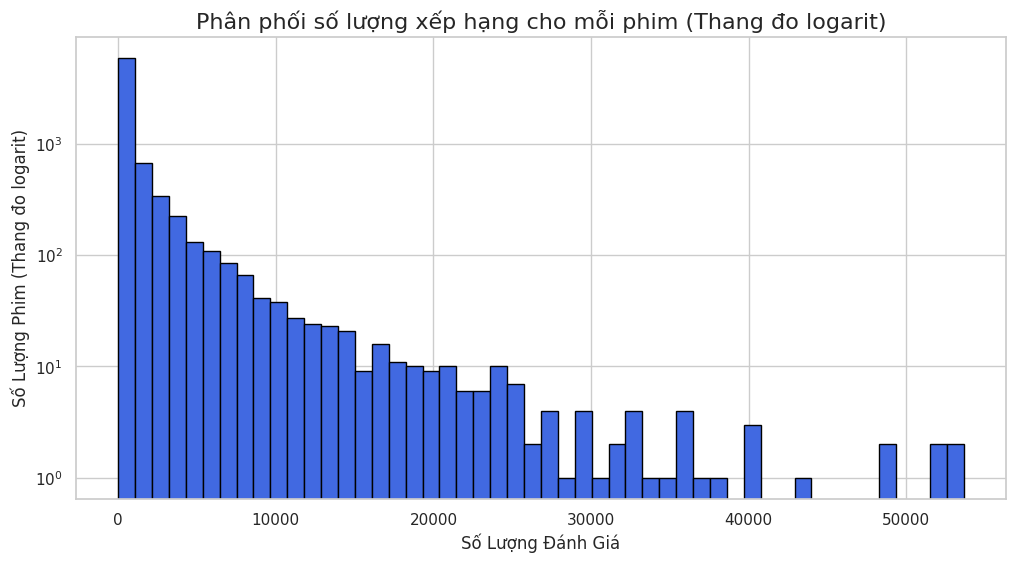

In [7]:
# Nhóm theo tiêu đề phim và đếm số lượt đánh giá cho mỗi phim
movie_ratings_count = df.groupby('title')['rating'].count()
plt.figure(figsize=(12, 6))
plt.hist(movie_ratings_count, bins=50, color='royalblue', edgecolor='black', log=True)
plt.title('Phân phối số lượng xếp hạng cho mỗi phim (Thang đo logarit)', fontsize=16)
plt.xlabel('Số Lượng Đánh Giá', fontsize=12)
plt.ylabel('Số Lượng Phim (Thang đo logarit)', fontsize=12)
plt.show()

Biểu đồ histogram xác nhận giả thuyết của chúng tôi. Phân phối bị lệch rất nhiều sang phải. Trục y được biểu diễn theo thang logarit để dễ dàng quan sát mô hình; nếu không có nó, các thanh biểu diễn của những bộ phim ít phổ biến hơn sẽ quá nhỏ để nhìn thấy. Biểu đồ này cho thấy một lượng lớn phim có ít hơn 100 lượt đánh giá, trong khi một nhóm phim rất nhỏ, tinh hoa, đã được đánh giá hàng chục nghìn lần. Đây là một phân phối đuôi dài kinh điển và là một đặc điểm chính của các tập dữ liệu hệ thống đề xuất.

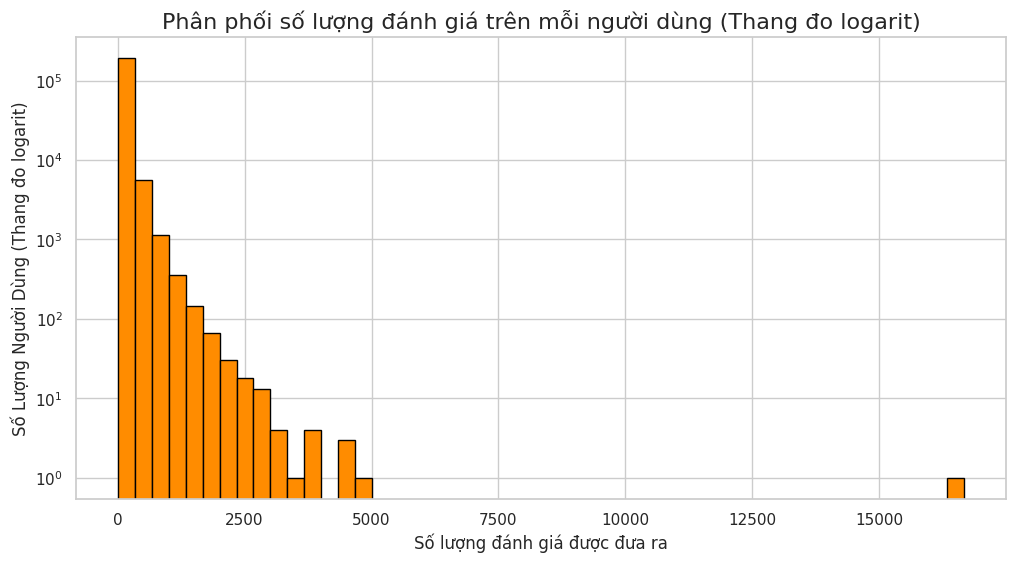

In [8]:
# Nhóm theo userId và đếm số lượng xếp hạng cho mỗi người dùng
user_ratings_count = df.groupby('userId')['rating'].count()
plt.figure(figsize=(12, 6))
plt.hist(user_ratings_count, bins=50, color='darkorange', edgecolor='black', log=True)
plt.title('Phân phối số lượng đánh giá trên mỗi người dùng (Thang đo logarit)', fontsize=16)
plt.xlabel('Số lượng đánh giá được đưa ra', fontsize=12)
plt.ylabel('Số Lượng Người Dùng (Thang đo logarit)', fontsize=12)
plt.show()

Phân phối này cũng là một phân phối đuôi dài. Một lượng lớn người dùng đã đánh giá một số lượng phim tương đối nhỏ (bộ dữ liệu đã được lọc để chỉ bao gồm những người dùng có ít nhất 20 lượt đánh giá). Tuy nhiên, có một số "người dùng thành thạo" đã đánh giá hàng nghìn phim. Sự thưa thớt này - khi hầu hết người dùng chỉ tương tác với một phần rất nhỏ trong tổng số các mục - chính là thách thức cốt lõi mà các hệ thống đề xuất được thiết kế để giải quyết.

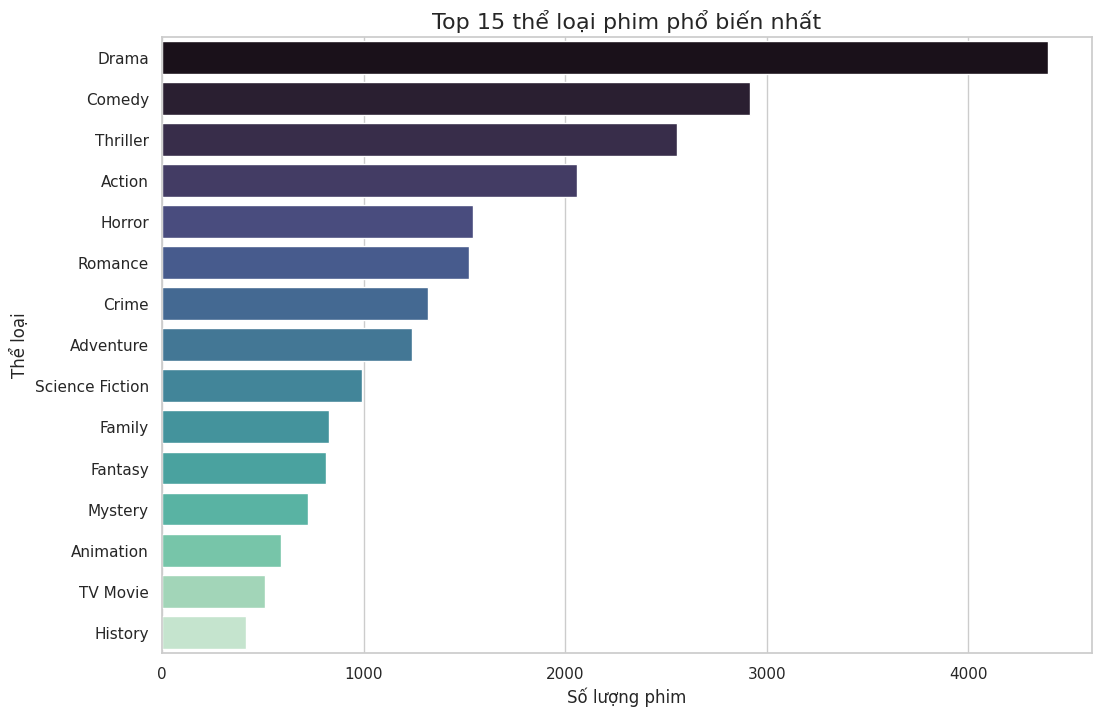

In [9]:
genre_df = movies_df.copy()
genre_df['genres'] = genre_df['genres'].str.split('|')
genre_df = genre_df.explode('genres')
genre_counts = genre_df['genres'].value_counts()

## Biểu đồ thể loại phim phổ biết
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_counts.head(15).values, y=genre_counts.head(15).index, palette='mako')
plt.title('Top 15 thể loại phim phổ biến nhất', fontsize=16)
plt.xlabel('Số lượng phim', fontsize=12)
plt.ylabel('Thể loại', fontsize=12)
plt.show()

Biểu đồ thanh cho thấy Thể loại Chính kịch và Hài kịch là hai thể loại phổ biến nhất trong tập dữ liệu. Tiếp theo là Phim kinh dị, Lãng mạn và Hành động. Danh mục "(không có thể loại nào được liệt kê)" thể hiện một số lượng nhỏ phim thiếu thông tin thể loại, đây là điều cần lưu ý đối với mô hình dựa trên nội dung của chúng tôi. Phân tích này cung cấp cho chúng tôi cái nhìn tổng quan tốt về nội dung chúng tôi đang xử lý.

# Model 1 - Collaborative Filtering

In [10]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

In [11]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)
model = SVD()
print("Training the model...")
model.fit(trainset)
print("Model training complete.")

print("\nMaking predictions on the test set...")
predictions = model.test(testset)
print("Predictions made.")

print("\nEvaluating model accuracy:")
accuracy.rmse(predictions)
accuracy.mae(predictions)

Training the model...
Model training complete.

Making predictions on the test set...
Predictions made.

Evaluating model accuracy:
RMSE: 0.8101
MAE:  0.6117


0.61172267055376

Các số liệu đánh giá cho chúng ta một bức tranh rõ nét về độ chính xác của mô hình. 
RMSE khoảng 0,81 có nghĩa là độ lệch chuẩn của các lỗi dự đoán của chúng ta là khoảng 0,81 sao. Với thang đánh giá 5 sao, đây là một kết quả rất đáng tin cậy. 
MAE khoảng 0,61 cho thấy, trung bình, dự đoán của mô hình chỉ sai lệch 0,61 sao. Đối với lần chạy đầu tiên mà không cần điều chỉnh siêu tham số, đây là những kết quả cơ sở mạnh mẽ. 
Chúng tôi đã xây dựng thành công một mô hình có thể dự đoán xếp hạng của người dùng với độ chính xác hợp lý. Bước tiếp theo là sử dụng mô hình đã được đào tạo này để tạo ra các đề xuất phim thực tế cho người dùng.

In [12]:
def get_top_n_recommendations(user_id, model, movies_df, n=10):
    all_movie_ids = movies_df['movieId'].unique()
    rated_movie_ids = df[df['userId'] == user_id]['movieId'].unique()
    unseen_movie_ids = np.setdiff1d(all_movie_ids, rated_movie_ids) #danh sách các bộ phim chưa xem
    predictions = [model.predict(user_id, movie_id) for movie_id in unseen_movie_ids] #dự đoán xếp hạng cho các bộ phim chưa xem
    predictions.sort(key=lambda x: x.est, reverse=True) #sắp xếp
    top_n_predictions = predictions[:n]
    #trích xuất id phim và xếp hạng các dự đoán hàng đầu
    top_movie_ids = [pred.iid for pred in top_n_predictions] 
    top_movie_ratings = {pred.iid: pred.est for pred in top_n_predictions}
    recommended_movies_df = movies_df[movies_df['movieId'].isin(top_movie_ids)].copy()
    #thêm đánh giá dự đoán
    recommended_movies_df['predicted_rating'] = recommended_movies_df['movieId'].map(top_movie_ratings)
    
    return recommended_movies_df[['movieId', 'title', 'genres', 'predicted_rating']].sort_values(
        'predicted_rating', ascending=False
    )

In [13]:
# ví dụ
example_user_id = 2025

top_recommendations = get_top_n_recommendations(
    user_id=example_user_id, 
    model=model, 
    movies_df=movies_df, 
    n=10
)

print(f"Top 10 phim được đề xuất hàng đầu cho người dùng: {example_user_id}")
display(top_recommendations)

Top 10 phim được đề xuất hàng đầu cho người dùng: 2025


,movieId,title,genres,predicted_rating
5193,5194,Lonely Planet,Romance|Drama,4.873433
669,670,Marquise,Drama|Comedy,4.832398
1177,1178,Halo: Nightfall,Science Fiction|Action|Adventure,4.825483
1220,1221,Blood Out,Action|Thriller,4.815803
49,50,xXx,Action|Adventure|Thriller|Crime|Drama,4.812153
2009,2010,The First Purge,Action|Horror|Thriller,4.810780
1948,1949,The Guardian,Action|Drama,4.809944
7668,7669,Revolver,Crime|Drama|Thriller,4.803594
1703,1704,Freedom Force,Animation|Adventure|Family,4.781495
8664,8665,Cosmic Sin,Science Fiction|Action|Adventure,4.778000


# Model 2 - Content-Based Filtering

In [14]:
# 1) Xử lý genres
movies_df['genres_processed'] = movies_df['genres'].str.replace('|', ' ', regex=False)
movies_df['genres_processed'] = movies_df['genres_processed'].fillna('')

# 2) Xử lý overview (thay NaN = rỗng)
movies_df['overview_processed'] = movies_df['overview'].fillna('')

# 3) TF-IDF cho genres
tfidf_genres = TfidfVectorizer(stop_words='english')
tfidf_matrix_genres = tfidf_genres.fit_transform(movies_df['genres_processed'])

# 4) TF-IDF cho overview
tfidf_overview = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix_overview = tfidf_overview.fit_transform(movies_df['overview_processed'])

print("Genres TF-IDF:", tfidf_matrix_genres.shape)
print("Overview TF-IDF:", tfidf_matrix_overview.shape)

# 5) Kết hợp genres + overview
from scipy.sparse import hstack

tfidf_combined = hstack([tfidf_matrix_genres, tfidf_matrix_overview])

print("Combined TF-IDF matrix shape:", tfidf_combined.shape)

Genres TF-IDF: (9892, 21)
Overview TF-IDF: (9892, 5000)
Combined TF-IDF matrix shape: (9892, 5021)


In [15]:
print("Calculating cosine similarity matrix... (This may take a moment)")

# Tính toán cosine similarity
cosine_sim = cosine_similarity(tfidf_combined, tfidf_combined)

print("Cosine similarity matrix calculated.")

print(f"\nShape of the cosine similarity matrix: {cosine_sim.shape}")

print("\nA slice of the similarity matrix (first 5x5 movies):")
similarity_slice = pd.DataFrame(cosine_sim[:5, :5], 
                                index=range(5), 
                                columns=range(5))
display(similarity_slice)


Calculating cosine similarity matrix... (This may take a moment)
Cosine similarity matrix calculated.

Shape of the cosine similarity matrix: (9892, 9892)

A slice of the similarity matrix (first 5x5 movies):


,0,1,2,3,4
0,1.000000,0.000000,0.104609,0.000000,0.000000
1,0.000000,1.000000,0.116488,0.134546,0.500000
2,0.104609,0.116488,1.000000,0.432891,0.125559
3,0.000000,0.134546,0.432891,1.000000,0.134546
4,0.000000,0.500000,0.125559,0.134546,1.000000


In [16]:
def get_content_based_recommendations(title, cosine_sim=cosine_sim, movies_df=movies_df):

    if title not in indices:
        return f"Movie '{title}' not found."

    idx = indices[title]

    # LẤY VECTOR 1D ĐÚNG CHUẨN
    sim_scores = list(enumerate(cosine_sim[idx].tolist()))

    # SORT OK
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Lấy top 10
    sim_scores = sim_scores[1:11]

    movie_indices = [i[0] for i in sim_scores]

    return movies_df[['title', 'genres', 'overview']].iloc[movie_indices]


In [17]:
# Choose a movie to get recommendations for
movie_title = 'Zootopia 2'
movies_df = movies_df.reset_index(drop=True)
indices = pd.Series(movies_df.index, index=movies_df['title']).drop_duplicates()
# Generate recommendations using our function
recommendations = get_content_based_recommendations(movie_title)

# Display the recommendations
print(f"Recommendations for viewers who liked '{movie_title}':")
display(recommendations)

Recommendations for viewers who liked 'Zootopia 2':


,title,genres,overview
20,Zootopia,Animation|Adventure|Family|Comedy,"Determined to prove herself, Officer Judy Hopp..."
4496,Wallace & Gromit: The Curse of the Were-Rabbit,Adventure|Animation|Comedy|Family,Cheese-loving eccentric Wallace and his cunnin...
5924,A Matter of Loaf and Death,Family|Animation|Comedy|Mystery,"Wallace and Gromit open a bakery, accidentally..."
2984,PAW Patrol: The Movie,Family|Comedy|Adventure|Animation,Ryder and the pups are called to Adventure Cit...
5899,Smurfs: The Lost Village,Family|Comedy|Adventure|Animation,"In this fully animated, all-new take on the Sm..."
4828,The SpongeBob Movie: Sponge on the Run,Family|Comedy|Adventure|Animation,When his best friend Gary is suddenly snatched...
732,Cars 3,Animation|Adventure|Comedy|Family,Blindsided by a new generation of blazing-fast...
2222,Madagascar 3: Europe's Most Wanted,Animation|Family|Comedy|Adventure,"Animal pals Alex, Marty, Melman, and Gloria ar..."
322,Madagascar,Family|Animation|Adventure|Comedy,Four animal friends get a taste of the wild li...
924,Cars,Animation|Adventure|Comedy|Family,"Lightning McQueen, a hotshot rookie race car d..."


In [18]:
# Generate recommendations for 'Toy Story (1995)'
recommendations_toy_story = get_content_based_recommendations('Jurassic Park')

print(f"\nRecommendations for viewers who liked 'Jurassic Park':")
display(recommendations_toy_story)


Recommendations for viewers who liked 'Jurassic Park':


,title,genres,overview
1060,Jurassic World,Action|Adventure|Science Fiction|Thriller,Twenty-two years after the events of Jurassic ...
2328,Futureworld,Action|Adventure|Science Fiction|Thriller,Two years after the Westworld tragedy in the D...
8369,The Incredible Shrinking Man,Adventure|Science Fiction,"Paul, is an ordinary man who divides his life ..."
8270,King of Painting,Adventure|Science Fiction,"Ke Huan is a talented and dreamy painter, but ..."
492,Jurassic World Dominion,Adventure|Action|Science Fiction,"Four years after Isla Nublar was destroyed, di..."
56,Jurassic World Rebirth,Science Fiction|Adventure|Action,Five years after the events of Jurassic World ...
195,Dune,Science Fiction|Adventure,"Paul Atreides, a brilliant and gifted young ma..."
352,Dune: Part Two,Science Fiction|Adventure,Follow the mythic journey of Paul Atreides as ...
2837,Fantastic Voyage,Science Fiction|Adventure,"In order to save an assassinated scientist, a ..."
2913,Lost Continent,Science Fiction|Adventure,When an experimental atomic rocket crashes som...


# Model 3: hybrid Recommendation System 

In [19]:
def get_hybrid_recommendations(user_id, title, model, cosine_sim, movies_df, n=10):
    """
    Generates hybrid recommendations by re-ranking content-based candidates
    with a collaborative filtering model.
    """

    # 1) Lấy vị trí phim theo title
    if title not in indices:
        return f"Movie with title '{title}' not found in the dataset."
    idx = indices[title]  # đây là vị trí (0..N-1)

    # 2) Lấy hàng similarity tương ứng phim đó
    row = cosine_sim[idx]

    # Ép về vector 1D
    try:
        row = row.toarray().ravel()      # nếu là sparse
    except AttributeError:
        row = np.array(row).ravel()      # nếu là ndarray

    # 3) Tạo list (index, similarity)
    sim_scores = list(enumerate(row))

    # 4) Sắp xếp theo similarity giảm dần
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 5) Lấy top 30 phim tương tự, bỏ phim gốc
    sim_scores = sim_scores[1:31]

    # 6) Lấy indices nhưng CHỈ giữ index hợp lệ (an toàn)
    max_idx = len(movies_df)
    movie_indices = [i for (i, score) in sim_scores if 0 <= i < max_idx]

    # Nếu lỡ ít hơn 30 phim hợp lệ, không sao
    candidate_movies = movies_df.iloc[movie_indices]

    # 7) Dự đoán rating bằng CF
    predictions = []
    for movie_id in candidate_movies['movieId']:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    pred_df = pd.DataFrame(predictions, columns=['movieId', 'predicted_rating'])

    # 8) Gộp lại và trả về top N
    final_recommendations = pd.merge(candidate_movies, pred_df, on='movieId')
    final_recommendations = final_recommendations.sort_values(
        'predicted_rating', ascending=False
    ).head(n)

    return final_recommendations[['movieId', 'title', 'genres', 'predicted_rating']]


In [20]:
# Pick the same user and a movie to get recommendations for
example_user_id = 1024
movie_title = 'Candyman'

# Generate hybrid recommendations
hybrid_recommendations = get_hybrid_recommendations(
    user_id=example_user_id,
    title=movie_title,
    model=model,
    cosine_sim=cosine_sim,
    movies_df=movies_df,
    n=10
)

print(f"Hybrid Recommendations for User {example_user_id} (based on '{movie_title}'):")
display(hybrid_recommendations)

Hybrid Recommendations for User 1024 (based on 'Candyman'):


,movieId,title,genres,predicted_rating
5,4291,Shrew's Nest,Horror|Thriller|Drama,4.042964
0,389,The Book,Horror|Thriller,4.018570
3,9427,Somewhere Quiet,Drama|Thriller|Horror,4.013597
1,3413,Aurora 15,Thriller|Horror,3.639791
4,7723,Special Effects,Drama|Horror|Thriller,3.446960
2,6827,The Eye,Drama|Horror|Thriller,2.348369


In [21]:
# ==== 1. TẠO ARTIFACTS TỪ NOTEBOOK TRAIN ====
import os, pickle, json
from surprise import dump as sp_dump
from scipy import sparse
import numpy as np

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1) Lưu model SVD (Surprise)
sp_dump.dump(os.path.join(ARTIFACT_DIR, "svd_model"), algo=model)

# 2) Lưu movies (để tra cứu title/genres)
movies_export = movies_df[['movieId','title','genres','poster_path','year']].drop_duplicates()
movies_export.to_csv(os.path.join(ARTIFACT_DIR, "movies.csv"), index=False)

# 3) Lưu TF-IDF vectorizers (genres + overview)
with open(os.path.join(ARTIFACT_DIR, "tfidf_genres.pkl"), "wb") as f:
    pickle.dump(tfidf_genres, f)

with open(os.path.join(ARTIFACT_DIR, "tfidf_overview.pkl"), "wb") as f:
    pickle.dump(tfidf_overview, f)

# Lưu ma trận TF-IDF đã kết hợp để dùng lại trong API
sparse.save_npz(os.path.join(ARTIFACT_DIR, "tfidf_combined.npz"), tfidf_combined)


# 4) Lưu map title->index để truy xuất nhanh
title_to_index = movies_df['title'].drop_duplicates().reset_index().set_index('title')['index'].to_dict()
with open(os.path.join(ARTIFACT_DIR, "title_to_index.pkl"), "wb") as f:
    pickle.dump(title_to_index, f)

# 5) Lưu danh sách all movie ids
all_movie_ids = movies_df['movieId'].astype(int).unique()
np.save(os.path.join(ARTIFACT_DIR, "all_movie_ids.npy"), all_movie_ids)

# 6) Lưu map userId -> set(movieId đã xem) để loại trừ khi gợi ý
user_seen_map = df.groupby('userId')['movieId'].apply(lambda s: set(s.astype(int))).to_dict()
with open(os.path.join(ARTIFACT_DIR, "user_seen_map.pkl"), "wb") as f:
    pickle.dump(user_seen_map, f)

print("Saved artifacts to:", ARTIFACT_DIR)


✅ Saved artifacts to: artifacts
